In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

In [30]:
df= pd.read_csv("E:\VS Code\Landing-Page-Optimization-Analytics\Dataset\AB Testing Data.csv")

In [31]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 294478
Columns : 12


In [32]:
df.head()

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount
0,U1,2025-08-02 15:27:54.137058,control,old_page,0,37,Male,Pakistan,3.69,4,Mobile,0.0
1,U2,2024-04-22 10:22:51.712050,treatment,new_page,0,31,Female,UK,1.29,3,Desktop,0.0
2,U3,2024-08-14 21:35:11.135894,treatment,new_page,0,38,Male,US,3.72,5,Desktop,0.0
3,U4,2025-03-19 03:28:51.120807,treatment,new_page,0,28,Female,India,7.76,2,Mobile,0.0
4,U5,2024-12-22 13:13:17.973162,control,old_page,0,33,Male,Australia,6.78,6,Mobile,0.0


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           294478 non-null  object 
 1   timestamp         294478 non-null  object 
 2   group             294478 non-null  object 
 3   landing_page      294478 non-null  object 
 4   converted         294478 non-null  int64  
 5   age               294478 non-null  int64  
 6   gender            294478 non-null  object 
 7   location          294478 non-null  object 
 8   session_duration  294478 non-null  float64
 9   pages_visited     294478 non-null  int64  
 10  device_type       294478 non-null  object 
 11  purchase_amount   294478 non-null  float64
dtypes: float64(2), int64(3), object(7)
memory usage: 27.0+ MB


In [34]:
df.describe()

,converted,age,session_duration,pages_visited,purchase_amount
count,294478.000000,294478.000000,294478.000000,294478.000000,294478.000000
mean,0.149172,31.902084,5.002136,4.019550,5.610490
std,0.356259,9.250043,1.980285,1.965182,15.438006
min,0.000000,18.000000,0.500000,1.000000,0.000000
25%,0.000000,25.000000,3.640000,3.000000,0.000000
50%,0.000000,32.000000,4.990000,4.000000,0.000000
75%,0.000000,38.000000,6.340000,5.000000,0.000000
max,1.000000,65.000000,13.730000,18.000000,269.280000


In [35]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
user_id,0,0.0
timestamp,0,0.0
group,0,0.0
landing_page,0,0.0
converted,0,0.0
...,...,...
location,0,0.0
session_duration,0,0.0
pages_visited,0,0.0
device_type,0,0.0


In [36]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [37]:
duplicate_users = df.user_id.duplicated().sum()

print(duplicate_users)

0


In [38]:
categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
    print("="*40)
    print(df[col].value_counts())
    print()

user_id
U1         1
U2         1
U3         1
U4         1
U5         1
          ..
U294474    1
U294475    1
U294476    1
U294477    1
U294478    1
Name: count, Length: 294478, dtype: int64

timestamp
2025-08-02 15:27:54.137058    1
2024-04-22 10:22:51.712050    1
2024-08-14 21:35:11.135894    1
2025-03-19 03:28:51.120807    1
2024-12-22 13:13:17.973162    1
                             ..
2024-07-30 06:05:54.675669    1
2025-02-06 21:33:14.387317    1
2024-08-06 09:34:42.463464    1
2024-03-30 07:32:55.891444    1
2025-05-23 23:10:22.739522    1
Name: count, Length: 294478, dtype: int64

group
treatment    147552
control      146926
Name: count, dtype: int64

landing_page
new_page    147552
old_page    146926
Name: count, dtype: int64

gender
Male      144708
Female    143785
Other       5985
Name: count, dtype: int64

location
US           88342
India        59014
UK           44217
Pakistan     29600
Germany      29477
Canada       29241
Australia    14587
Name: count, dtype: int

In [39]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['converted', 'age', 'session_duration', 'pages_visited',
       'purchase_amount'],
      dtype='object')

In [40]:
df.age.describe()

count    294478.000000
mean         31.902084
std           9.250043
min          18.000000
25%          25.000000
50%          32.000000
75%          38.000000
max          65.000000
Name: age, dtype: float64

In [41]:
df.session_duration.describe()

count    294478.000000
mean          5.002136
std           1.980285
min           0.500000
25%           3.640000
50%           4.990000
75%           6.340000
max          13.730000
Name: session_duration, dtype: float64

In [42]:
df.pages_visited.describe()

count    294478.000000
mean          4.019550
std           1.965182
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max          18.000000
Name: pages_visited, dtype: float64

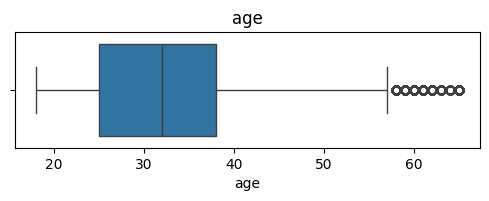

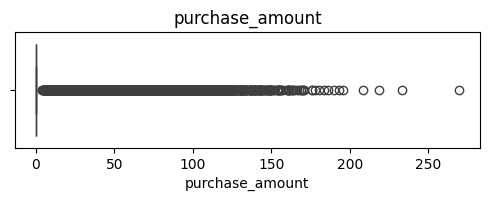

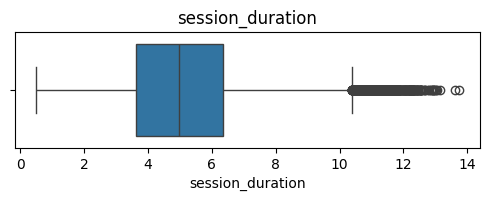

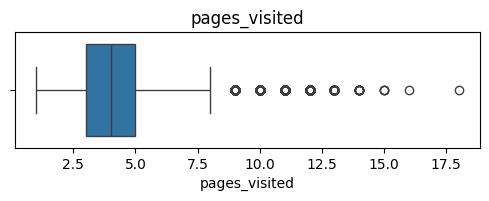

In [43]:
for col in [

    "age",

    "purchase_amount",

    "session_duration",

    "pages_visited"

]:

    plt.figure(figsize=(6,1.5))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [44]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["hour"] = df["timestamp"].dt.hour

In [45]:
df["day"] = df["timestamp"].dt.day_name()

In [46]:
df["month"] = df["timestamp"].dt.month_name()

In [47]:
df["is_weekend"] = (
    df["timestamp"]
      .dt.dayofweek
      .isin([5,6])
)

In [48]:
bins = [18,25,35,45,60,100]

labels = [

    "18-24",

    "25-34",

    "35-44",

    "45-59",

    "60+"

]

df["age_group"] = pd.cut(

    df.age,

    bins=bins,

    labels=labels,

    right=False
)

In [49]:
df["revenue_category"] = np.where(

    df.purchase_amount > 0,

    "Purchaser",

    "Non-Purchaser"

)

In [50]:
df.info()

df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           294478 non-null  object        
 1   timestamp         294478 non-null  datetime64[ns]
 2   group             294478 non-null  object        
 3   landing_page      294478 non-null  object        
 4   converted         294478 non-null  int64         
 5   age               294478 non-null  int64         
 6   gender            294478 non-null  object        
 7   location          294478 non-null  object        
 8   session_duration  294478 non-null  float64       
 9   pages_visited     294478 non-null  int64         
 10  device_type       294478 non-null  object        
 11  purchase_amount   294478 non-null  float64       
 12  hour              294478 non-null  int32         
 13  day               294478 non-null  object        
 14  mont

,user_id,timestamp,group,landing_page,converted,age,gender,location,session_duration,pages_visited,device_type,purchase_amount,hour,day,month,is_weekend,age_group,revenue_category
count,294478,294478,294478,294478,294478.000000,294478.000000,294478,294478,294478.000000,294478.000000,294478,294478.000000,294478.000000,294478,294478,294478,294478,294478
unique,294478,NaN,2,2,NaN,NaN,3,7,NaN,NaN,3,NaN,NaN,7,12,2,5,2
top,U1,NaN,treatment,new_page,NaN,NaN,Male,US,NaN,NaN,Desktop,NaN,NaN,Wednesday,December,False,25-34,Non-Purchaser
freq,1,NaN,147552,147552,NaN,NaN,144708,88342,NaN,NaN,176692,NaN,NaN,42531,25147,210471,110439,250550
mean,NaN,2024-08-30 00:06:05.604994048,NaN,NaN,0.149172,31.902084,NaN,NaN,5.002136,4.019550,NaN,5.610490,11.477560,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25%,NaN,2024-02-29 09:33:19.255553536,NaN,NaN,0.000000,25.000000,NaN,NaN,3.640000,3.000000,NaN,0.000000,5.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,2024-08-29 19:58:01.327865344,NaN,NaN,0.000000,32.000000,NaN,NaN,4.990000,4.000000,NaN,0.000000,11.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,2025-02-28 17:52:31.882533888,NaN,NaN,0.000000,38.000000,NaN,NaN,6.340000,5.000000,NaN,0.000000,17.000000,NaN,NaN,NaN,NaN,NaN
max,NaN,2025-08-30 09:48:09.479117,NaN,NaN,1.000000,65.000000,NaN,NaN,13.730000,18.000000,NaN,269.280000,23.000000,NaN,NaN,NaN,NaN,NaN


In [51]:
df.to_csv(

    "../Output/cleaned_data.csv",

    index=False
)
